<style>
  .no-break {
    page-break-inside: avoid;
  }
</style>


<h1>Does Bedtime Matter?</h1>

<h2>Investigating the Relationship Between Sleep Duration, Bedtime, and Sleep Quality</h2>

<p>
Sleep is often reduced to a simple question of <strong>how many hours were slept</strong>. 
However, the time at which sleep occurs may also influence how restorative that sleep is.
</p>

<p>
This notebook investigates the relationship between <strong>bedtime, sleep duration, and sleep quality</strong> 
using approximately <strong>1300 consecutive days</strong> of personal Garmin sleep data.
</p>

<div style="margin: 20px 0; padding: 12px; border-left: 4px solid #4CAF50; background: #f9f9f9;">
  <strong>Central Question:</strong><br>
  Does bedtime have an effect on sleep quality beyond simply determining how long sleep is?
</div>

<p>
This question is important because bedtime and sleep duration are strongly related. 
A later bedtime generally results in less sleep, particularly when wake-up time is constrained. 
Therefore, an observed relationship between late bedtimes and poorer sleep does not necessarily mean 
that bedtime itself is responsible — it may simply reflect insufficient sleep.
</p>

<p>To separate these effects, the analysis progressively examines:</p>

<ul>
  <li><strong>How bedtime affects sleep duration</strong></li>
  <li><strong>Whether bedtime remains associated with sleep metrics when sleep duration is accounted for</strong></li>
  <li><strong>How much sleep duration matters compared with bedtime</strong></li>
  <li><strong>Whether the relative importance of bedtime changes across different sleep-duration ranges</strong></li>
</ul>

<p>
The analysis combines exploratory visualisation with statistical modelling, including correlation analysis, 
regression, interaction effects, robust regression, and variance-explanation methods.
</p>

<p>
The aim is not to identify a single <em>perfect bedtime</em>, but to determine 
<strong>whether bedtime timing provides meaningful information about sleep quality once the dominant effect of sleep duration has been considered</strong>.
</p>

<blockquote style="border-left: 4px solid #2196F3; padding-left: 12px; background: #f5faff;">
  <strong>Note:</strong> This is an observational analysis of a single individual's Garmin data. 
  The results therefore describe associations within this dataset rather than establishing causal or generalisable effects.
</blockquote>


<p style="page-break-after: always;"></p>

In [ ]:
import sys, os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)


import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr


from src.utils.feature_engineering.sleep_features import add_sleep_features
from src.utils.binning import assign_sleep_bins, assign_bedtime_bins
from src.analysis.stats import calculate_hierarchical_r2, calculate_binned_r2_breakdown
from src.plots.sleep_plots import (plot_bedtime_distribution, plot_sleep_duration_distribution, plot_bedtime_vs_sleep_duration, 
                        plot_bedtime_vs_wake_time, plot_binned_bedtime, plot_metric_heatmaps, plot_r2_breakdown)
from src.tables.correlation_tables import pearsonr_table
from src.tables.hierarchical_tables import build_hierarchical_r2_table
from src.analysis.aggregation import compute_binned_sleep_metrics, compute_binned_sleep_stats


<div class="no-break">

<h1>Getting set up</h1>

<h2>Loading the data</h2>

<p>
To begin the analysis, the cleaned sleep dataset is loaded directly from the SQL database. 
This provides access to all nightly sleep metrics, timestamps, and features used throughout the notebook.
</p>

</div>


In [5]:

con = sqlite3.connect(r"C:\Users\Dexta\Learning\Garmin-Analysis\data\garmin.db")

sleep_df = pd.read_sql(
    "SELECT * FROM Sleep",
    con
)

<div class="no-break">

<h2>Feature Engineering</h2>

<p>
Before beginning the analysis, several additional variables are derived from the raw Garmin data. 
These transformations make the dataset easier to analyse and allow bedtime, sleep duration, and sleep quality 
to be compared consistently.
</p>

<p>
These engineered features form the foundation for all subsequent modelling, visualisation, and statistical interpretation.
</p>

<table style="border-collapse: collapse; width: 100%; margin-top: 15px;">
  <thead>
    <tr style="background: #f2f2f2;">
      <th style="padding: 8px; text-align: left;">Feature</th>
      <th style="padding: 8px; text-align: left;">Description</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 8px;"><code>decimalStartTime</code></td>
      <td style="padding: 8px;">
        Bedtime represented as decimal hours (e.g., 21:15 → 21.25). 
        Bedtimes after midnight are shifted beyond 24:00 so that the sleep period remains continuous.
      </td>
    </tr>
    <tr>
      <td style="padding: 8px;"><code>decimalEndTime</code></td>
      <td style="padding: 8px;">Wake time represented as decimal hours.</td>
    </tr>
    <tr>
      <td style="padding: 8px;"><code>sleep_hours</code></td>
      <td style="padding: 8px;">Total sleep duration in hours, calculated from Garmin's recorded sleep seconds.</td>
    </tr>
    <tr>
      <td style="padding: 8px;"><code>hours_in_bed</code></td>
      <td style="padding: 8px;">Total elapsed time between falling asleep and waking.</td>
    </tr>
    <tr>
      <td style="padding: 8px;"><code>centered_sleep_hours</code></td>
      <td style="padding: 8px;">Sleep duration expressed as the deviation from mean sleep duration.</td>
    </tr>
    <tr>
      <td style="padding: 8px;"><code>centered_bed_time</code></td>
      <td style="padding: 8px;">Bedtime expressed as the deviation from mean bedtime.</td>
    </tr>
  </tbody>
</table>

<p style="margin-top: 20px;">
With these features computed, the dataset is ready for schedule analysis and the exploration of bedtime - sleep relationships.
</p>

</div>


In [6]:
sleep_df = add_sleep_features(sleep_df)

<div class="no-break">

<h2>Understanding the Sleep Schedule</h2>

<p>
Before investigating whether bedtime affects sleep quality, we first need to understand the basic 
structure of the sleep data. Establishing this baseline is essential: if later bedtimes are consistently 
associated with shorter sleep, then any relationship between bedtime and sleep quality may simply 
reflect reduced sleep duration rather than bedtime itself.
</p>

<div style="margin: 20px 0; padding: 12px; border-left: 4px solid #4CAF50; background: #f9f9f9;">
  <strong>Key Question:</strong><br>
  What does a typical night of sleep look like, and how are bedtime, wake time, and sleep duration related?
</div>

<p>
To answer this, we begin by examining the fundamental components of the sleep schedule:
</p>

<ul style="margin-top: 10px;">
  <li>The distribution of sleep duration</li>
  <li>The distribution of bedtime</li>
  <li>The relationship between bedtime and sleep duration</li>
  <li>Whether later bedtimes are compensated for by later wake times</li>
</ul>

<p style="margin-top: 20px;">
These descriptive patterns form the foundation for all subsequent modelling and help clarify how 
behavioural timing influences nightly sleep quantity.
</p>

</div>


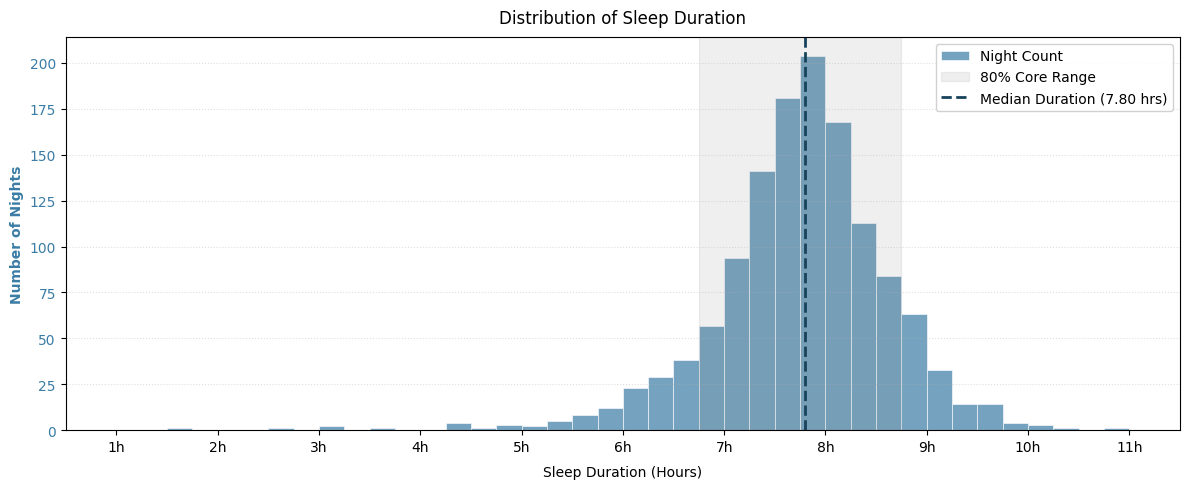

In [7]:
fig, ax= plot_sleep_duration_distribution(sleep_df, "sleep_hours")

plt.show()

<div>

<p>
The distribution of nightly sleep duration reveals several important structural characteristics of the dataset:
</p>

<ul style="margin-top: 10px;">
  <li>
    <strong>Core Baseline:</strong> Sleep duration is tightly clustered around a 
    <strong>median of 7.80 hours</strong>, with <strong>80% of all nights</strong> falling within a narrow 
    <strong>2‑hour window (6.75h to 8.75h)</strong>.
  </li>

  <li>
    <strong>Asymmetric Left Skew:</strong> The distribution shows a pronounced left‑side tail, reflecting 
    periodic sleep truncation where duration drops to <strong>4–5 hours</strong>, with rare outliers below 4 hours.
  </li>

  <li>
    <strong>Upper Bound:</strong> Extended sleep declines sharply past 9 hours, approaching a biological 
    ceiling around <strong>10 hours</strong>.
  </li>
</ul>

<div style="margin-top: 20px; padding: 12px; border-left: 4px solid #4CAF50; background: #f9f9f9;">
  <strong>Takeaway:</strong> Overall sleep volume is highly stable, with night‑to‑night variance driven almost 
  entirely by occasional sleep deprivation (left‑tail truncation) rather than oversleeping.
</div>

</div>


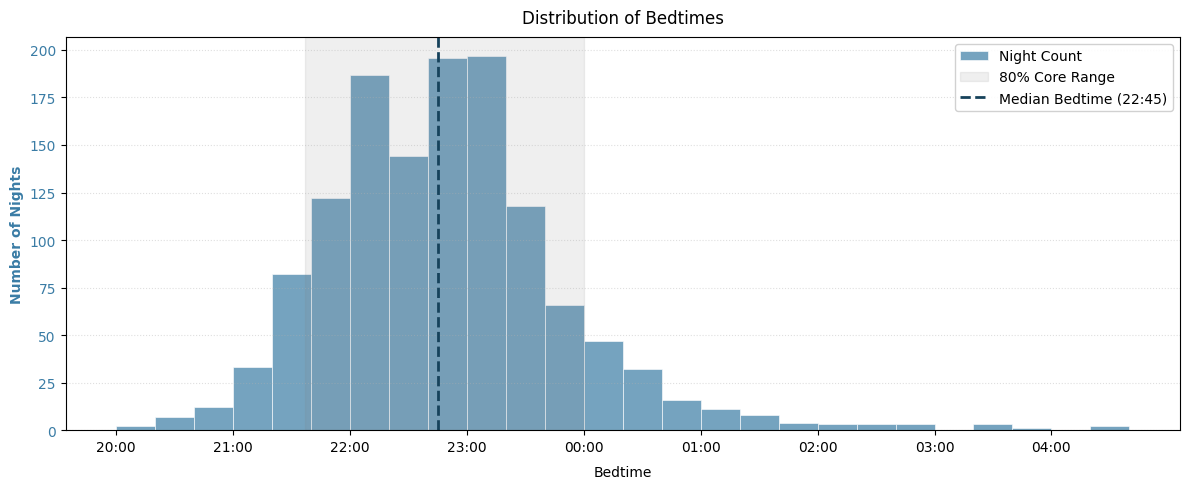

In [8]:

fig, ax = plot_bedtime_distribution(sleep_df, "decimalStartTime")

plt.show()

<div>

<p>
The distribution of bedtimes reveals a strong behavioural preference centred around a 
<strong>median bedtime of 22:45</strong>. This structure provides important context for understanding how 
sleep timing interacts with nightly sleep duration.
</p>

<ul style="margin-top: 10px;">
  <li>
    <strong>Consistent routine:</strong> Sleep timing is tightly clustered, with 
    <strong>80% of all nights occurring between 21:38 and 00:00</strong>.
  </li>

  <li>
    <strong>Occasional late nights:</strong> Early bedtimes (<21:00) are uncommon, but the distribution 
    exhibits a pronounced <strong>right‑hand tail</strong>, with some nights extending beyond 01:00 and as late as 04:30.
  </li>
</ul>

<p style="margin-top: 15px;">
This right‑hand tail closely mirrors the reduction in sleep duration observed in the previous section, 
suggesting that later bedtimes may systematically reduce the amount of sleep obtained.
</p>

<hr>

<h2>Exploring the relationship</h2>

<div class="no-break">

<p>
To formally quantify the relationships between bedtime, wake time, and sleep duration, we use the 
<strong>Pearson correlation coefficient</strong>. This provides a clear measure of how strongly two variables 
move together.
</p>

<h3>Pearson Correlation</h3>

<p>
The Pearson correlation coefficient (<em>r</em>) measures the strength and direction of the linear 
relationship between two continuous variables. Its value ranges from <strong>-1</strong> to <strong>1</strong>:
</p>

<ul style="margin-top: 10px;">
  <li><strong>r = 1</strong>: Perfect positive linear relationship.</li>
  <li><strong>r = 0</strong>: No linear relationship.</li>
  <li><strong>r = -1</strong>: Perfect negative linear relationship.</li>
</ul>

<p style="margin-top: 15px;">
The coefficient is calculated as:
</p>

</div>

$$
r = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}
         {\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2 \sum_{i=1}^{n} (y_i - \bar{y})^2}}
$$

<div class="no-break">

<p style="margin-top: 20px;">
To interpret each correlation, three statistics are reported:
</p>

<ul style="margin-top: 10px;">
  <li>
    <strong>Correlation (r):</strong> Indicates the <strong>direction</strong> and <strong>strength</strong> of the linear relationship. 
    A negative value means the variables move in opposite directions; a positive value means they move together.
  </li>

  <li>
    <strong>Coefficient of Determination (R²):</strong> Calculated as <em>R² = r²</em>. This represents the 
    proportion of variation in one variable that can be explained by the other.  
    For example, an R² of <strong>25%</strong> means that one quarter of the observed variation is explained by the linear relationship.
  </li>

  <li>
    <strong>Significance (p):</strong> Measures the probability of observing a relationship this strong by chance.  
    A value of <strong>p &lt; 0.05</strong> indicates that the relationship is statistically significant.
  </li>
</ul>

</div>



In [9]:

# correlation between bedtime and amount of sleep
r_bed_dur, p_bed_dur = pearsonr(sleep_df["decimalStartTime"], sleep_df["sleep_hours"])

# correlation between bedtime and wake time (total time in bed)
r_bed_wake, p_bed_wake = pearsonr(sleep_df["decimalStartTime"], sleep_df["decimalEndTime"])


display(pearsonr_table(r_bed_dur,r_bed_wake, p_bed_dur,p_bed_wake))


Schedule Metric,Correlation (r),R² (Variance),p-value
Bedtime vs. Sleep Length,-0.516,0.266 (26.6%),< 0.001
Bedtime vs. Wake Time (Sleeping In),+0.593,0.352 (35.2%),< 0.001


<div class="no-break">

<h3>Key Findings: Bedtime, Wake Time, and Sleep Duration</h3>

<p>
The Pearson correlations reveal a clear relationship between daily schedule and the amount of sleep obtained:
</p>

<ul style="margin-top: 10px;">
  <li>
    <strong>Later bedtimes reduce sleep duration</strong> 
    (r = -0.516, R² = 26.6%, p &lt; 0.001).  
    Approximately one quarter of the variation in nightly sleep duration can be explained by bedtime alone, 
    indicating that later bedtimes are consistently associated with shorter nights.
  </li>

  <li>
    <strong>Later wake times partially compensate</strong> 
    (r = +0.593, R² = 35.2%, p &lt; 0.001).  
    Sleeping in after a late bedtime helps recover some lost sleep, but this compensation is incomplete 
    and does not fully offset the delay in bedtime.
  </li>
</ul>

<div style="margin-top: 20px; padding: 12px; border-left: 4px solid #4CAF50; background: #f9f9f9;">
  Together, these results suggest that bedtime and wake time shift in the same direction, 
  but not by the same amount. On average, going to bed later still results in less total sleep, 
  even when wake-up time is allowed to vary.
</div>

<h3 style="margin-top: 30px;">Why This Matters</h3>

<p>
Sleep duration is determined by both <strong>bedtime</strong> and <strong>wake time</strong>:
</p>

</div>

$$
\text{Sleep Duration} = (\text{Wake Time} - \text{Bedtime}) - \text{Awake Time}
$$

<div class="no-break">

<p style="margin-top: 20px;">
Although later bedtimes are often accompanied by later wake times, the increase in wake time is generally 
smaller than the delay in bedtime. Consequently, each hour of delayed bedtime is associated with a net 
reduction in total sleep.
</p>

<p style="margin-top: 20px;">
The following scatter plots illustrate these relationships and show how bedtime and wake time each 
contribute to nightly sleep duration.
</p>

</div>


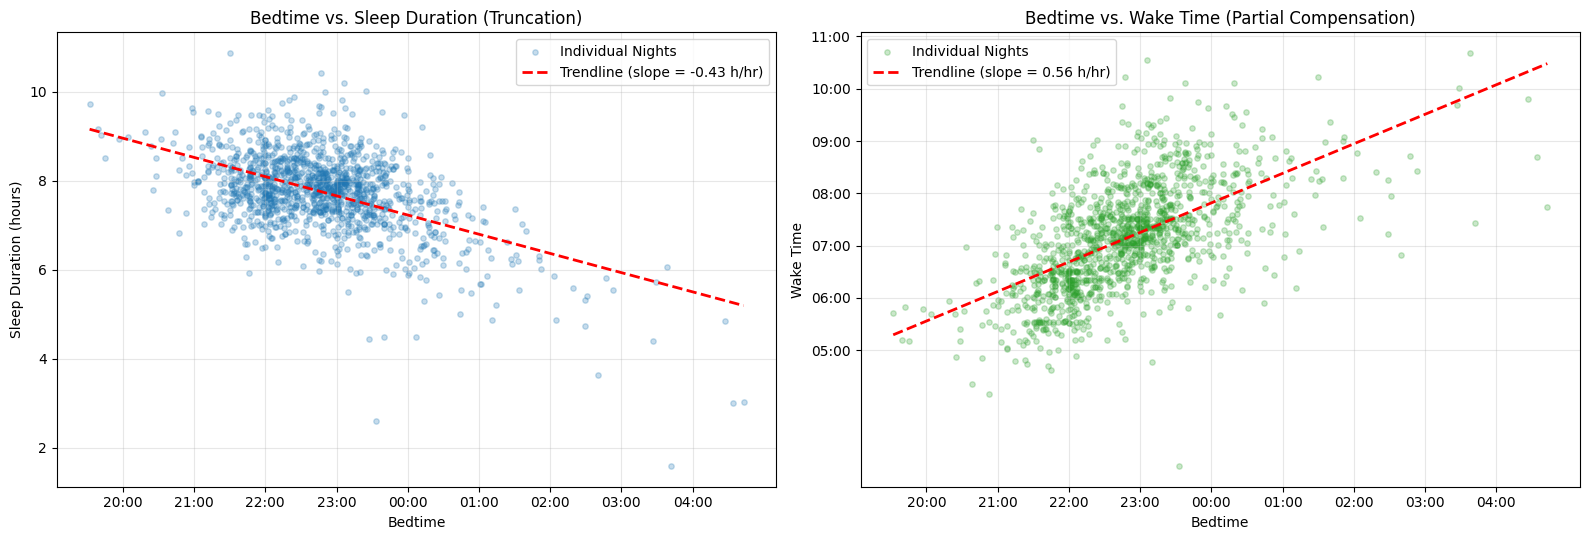

In [10]:
# calculate gradient and intercept
m_dur, c_dur = np.polyfit(sleep_df["decimalStartTime"], sleep_df["sleep_hours"], 1)
m_wake, c_wake = np.polyfit(sleep_df["decimalStartTime"], sleep_df["decimalEndTime"], 1)


# plotting
x_vals = np.linspace(sleep_df["decimalStartTime"].min(), sleep_df["decimalStartTime"].max(), 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))

plot_bedtime_vs_sleep_duration(ax1, sleep_df, x_vals, m_dur, c_dur)
plot_bedtime_vs_wake_time(ax2, sleep_df, x_vals, m_wake, c_wake)

plt.tight_layout()
plt.show()

<div class="no-break">

<h3>Interpretation: Schedule Dynamics & Trendline Slopes</h3>

<p>
The fitted trendlines allow the relationships observed in the scatter plots to be quantified:
</p>

<ul style="margin-top: 10px;">
  <li>
    <strong>Later bedtimes reduce sleep duration (m = -0.43 h/hr):</strong><br>
    On average, each <strong>1-hour delay in bedtime</strong> is associated with a reduction of approximately 
    <strong>0.43 hours (26 minutes)</strong> in total sleep duration. This provides a direct estimate of the 
    average sleep lost as bedtime shifts later.
  </li>

  <li style="margin-top: 10px;">
    <strong>Wake time partially compensates (m = +0.57 h/hr):</strong><br>
    Wake time is not fixed. For every <strong>1-hour delay in bedtime</strong>, wake time shifts later by 
    approximately <strong>0.57 hours (34 minutes)</strong>. This partial compensation recovers some of the 
    lost sleep, but not all of it.
  </li>

  <li style="margin-top: 10px;">
    <strong>Net effect on time in bed:</strong>
  </li>
</ul>

</div>

$$
\Delta \text{Time in Bed}
=
\Delta \text{Wake Time}
-
\Delta \text{Bedtime}
=
34 - 60
=
-26 \text{ minutes}
$$

<div class="no-break">

<p style="margin-top: 20px;">
On average, delaying bedtime by one hour reduces total time in bed by approximately 
<strong>26 minutes</strong>. Although later wake times offset part of the delay, they do not fully compensate 
for it, resulting in a consistent reduction in both time in bed and total sleep duration.
</p>

<hr style="margin: 30px 0;">

<p>
The scatter around each trendline reflects normal day-to-day variation arising from work or study 
commitments, training schedules, weekends, and other behavioural factors. While the overall relationship 
is clear, individual nights remain highly variable.
</p>

<p style="margin-top: 15px;">
To reveal the underlying behavioural pattern more clearly, the next section aggregates nights into 
<strong>30-minute bedtime intervals</strong>. Averaging within each bin reduces the influence of individual-night 
variability, making it easier to identify how sleep duration changes across progressively later bedtimes.
</p>

</div>


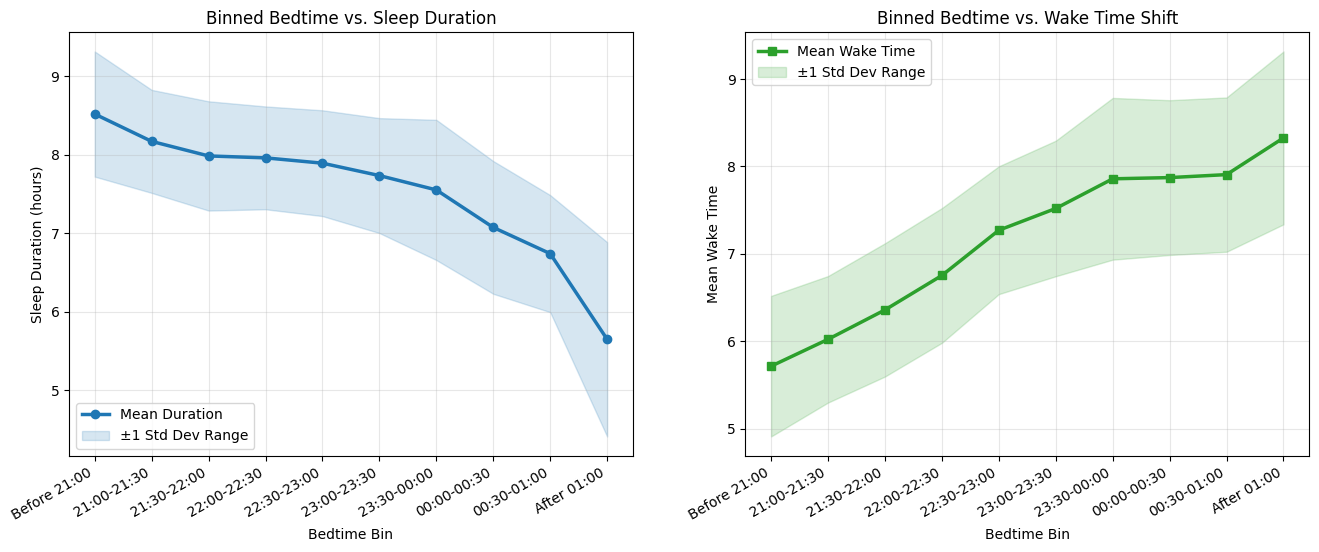

In [11]:
sleep_df = assign_bedtime_bins(sleep_df)
binned_sleep_df = compute_binned_sleep_stats(sleep_df)


fig, ax1, ax2 = plot_binned_bedtime(binned_sleep_df)


<div class="no-break">

<h2>Summary: Sleep Quantity Findings</h2>

<p>
We have examined how bedtime influences the <strong>amount of sleep</strong> obtained, beginning with basic 
schedule distributions and progressing through correlation analysis and binned behavioural trends.
</p>

<p>The main findings are:</p>

<ul style="margin-top: 10px;">
  <li>
    <strong>A highly consistent sleep schedule:</strong> Around 80% of nights began between 
    <strong>21:38 and 00:00</strong>, indicating a stable routine with only occasional very late nights.
  </li>

  <li style="margin-top: 10px;">
    <strong>Later bedtimes consistently reduce total sleep duration:</strong> Bedtime showed a strong and 
    statistically significant negative relationship with sleep duration (r = -0.516, p &lt; 0.001), explaining 
    roughly <strong>27%</strong> of the night‑to‑night variation in sleep length.
  </li>

  <li style="margin-top: 10px;">
    <strong>Sleeping in only partially compensates:</strong> Although wake time shifts later after late 
    bedtimes, this compensation is incomplete. Each one‑hour delay in bedtime results in approximately 
    <strong>26 minutes less time in bed</strong>, producing a net reduction in total sleep.
  </li>

  <li style="margin-top: 10px;">
    <strong>The relationship is robust:</strong> Both individual-night scatter plots and aggregated 
    30‑minute bedtime bins reveal the same behavioural pattern, demonstrating that the effect is consistent 
    across multiple analytical approaches and not driven by a small subset of nights.
  </li>
</ul>

<div style="margin-top: 20px; padding: 12px; border-left: 4px solid #4CAF50; background: #f9f9f9;">
  Up to here, we have shown that <strong>bedtime primarily determines how much sleep is obtained</strong>. 
  What remains unclear is whether bedtime also influences <strong>how restorative</strong> that sleep is.
</div>

</div>

<hr style="margin: 40px 0;">


<div class="no-break">

<h1>Does Bedtime Affect Sleep Quality?</h1>

<p>
A clear behavioural link between bedtime and <strong>sleep quantity</strong> has been established, a crucial question is left unanswered:
</p>

<div style="margin: 20px 0; padding: 12px; border-left: 4px solid #2196F3; background: #f5faff;">
  <strong>Does bedtime independently influence sleep quality, or is bedtime simply a proxy for obtaining less sleep?</strong>
</div>

<p>
Put differently: if two nights contain exactly the same amount of sleep, does <strong>when</strong> that sleep occurs 
still matter?
</p>

<h3>Key Questions</h3>

<ul style="margin-top: 10px;">
  <li>
    <strong>The Equal-Duration Test:</strong> Is an 8‑hour sleep beginning at <strong>22:00</strong> equivalent in 
    quality to an 8‑hour sleep beginning at <strong>00:30</strong>?
  </li>

  <li style="margin-top: 10px;">
    <strong>Component Sensitivity:</strong> If differences exist, which aspects of sleep are most affected? 
    Do late bedtimes impair <strong>deep sleep</strong>, <strong>REM sleep</strong>, <strong>recovery</strong>, or other physiological 
    measures even when total sleep duration is held constant?
  </li>
</ul>

</div>

<hr style="margin: 40px 0;">

<div class="no-break">

<h2>Method: 2D Bedtime x Sleep Duration Matrices</h2>

<p>
To answer these questions, the data are grouped simultaneously by <strong>sleep duration</strong> and 
<strong>bedtime</strong>, producing a series of two‑dimensional matrices.
</p>

<p>
This structure allows comparisons to be made <strong>within fixed sleep‑duration categories</strong>. Reading 
horizontally across a row isolates the effect of bedtime: any consistent change across that row reflects 
differences in bedtime rather than differences in total sleep obtained.
</p>

<h3>Matrix Structure</h3>

<ul style="margin-top: 10px;">
  <li><strong>Bedtime:</strong> 30‑minute intervals from <strong>before 21:00</strong> to <strong>after 01:00</strong>.</li>
  <li style="margin-top: 10px;"><strong>Sleep Duration:</strong> Four groups : <strong>&lt;7 hours</strong>, <strong>7–8 hours</strong>, <strong>8–9 hours</strong>, and <strong>9+ hours</strong>.</li>
</ul>

<h3>Sleep Metrics Analysed</h3>

<p>
For each bedtime × duration combination, the average values of the following Garmin metrics are computed:
</p>

<ul style="margin-top: 10px;">
  <li><strong>Overall Sleep Score</strong> : composite measure of sleep quality</li>
  <li><strong>REM Sleep Score</strong> : REM sleep performance</li>
  <li><strong>Deep Sleep Score</strong> : deep sleep performance</li>
  <li><strong>Light Sleep Score</strong> : light sleep component</li>
  <li><strong>Recovery Score</strong> : overnight physiological recovery</li>
  <li><strong>Average Sleep Stress</strong> : autonomic stress during sleep</li>
</ul>

<p style="margin-top: 20px;">
These metrics provide a multi‑dimensional view of sleep quality beyond duration alone.
</p>

</div>


In [12]:
analysis_df = sleep_df.copy()

analysis_df = assign_sleep_bins(analysis_df)
group_stats = compute_binned_sleep_metrics(analysis_df)


<div class="no-break">

<h3>Exploratory Heatmaps: Metric Distributions Across the Matrix</h3>

<p>
With the matrix framework established, we project the average scores across a 
<strong>2 × 3 heatmap grid</strong> to visually inspect macro trends across the sleep schedule.
</p>

<p>
To keep the heatmaps readable and prevent single-night outliers from distorting the color gradients, 
any matrix cell with <strong>fewer than 5 recorded nights is masked out.
</p>

</div>



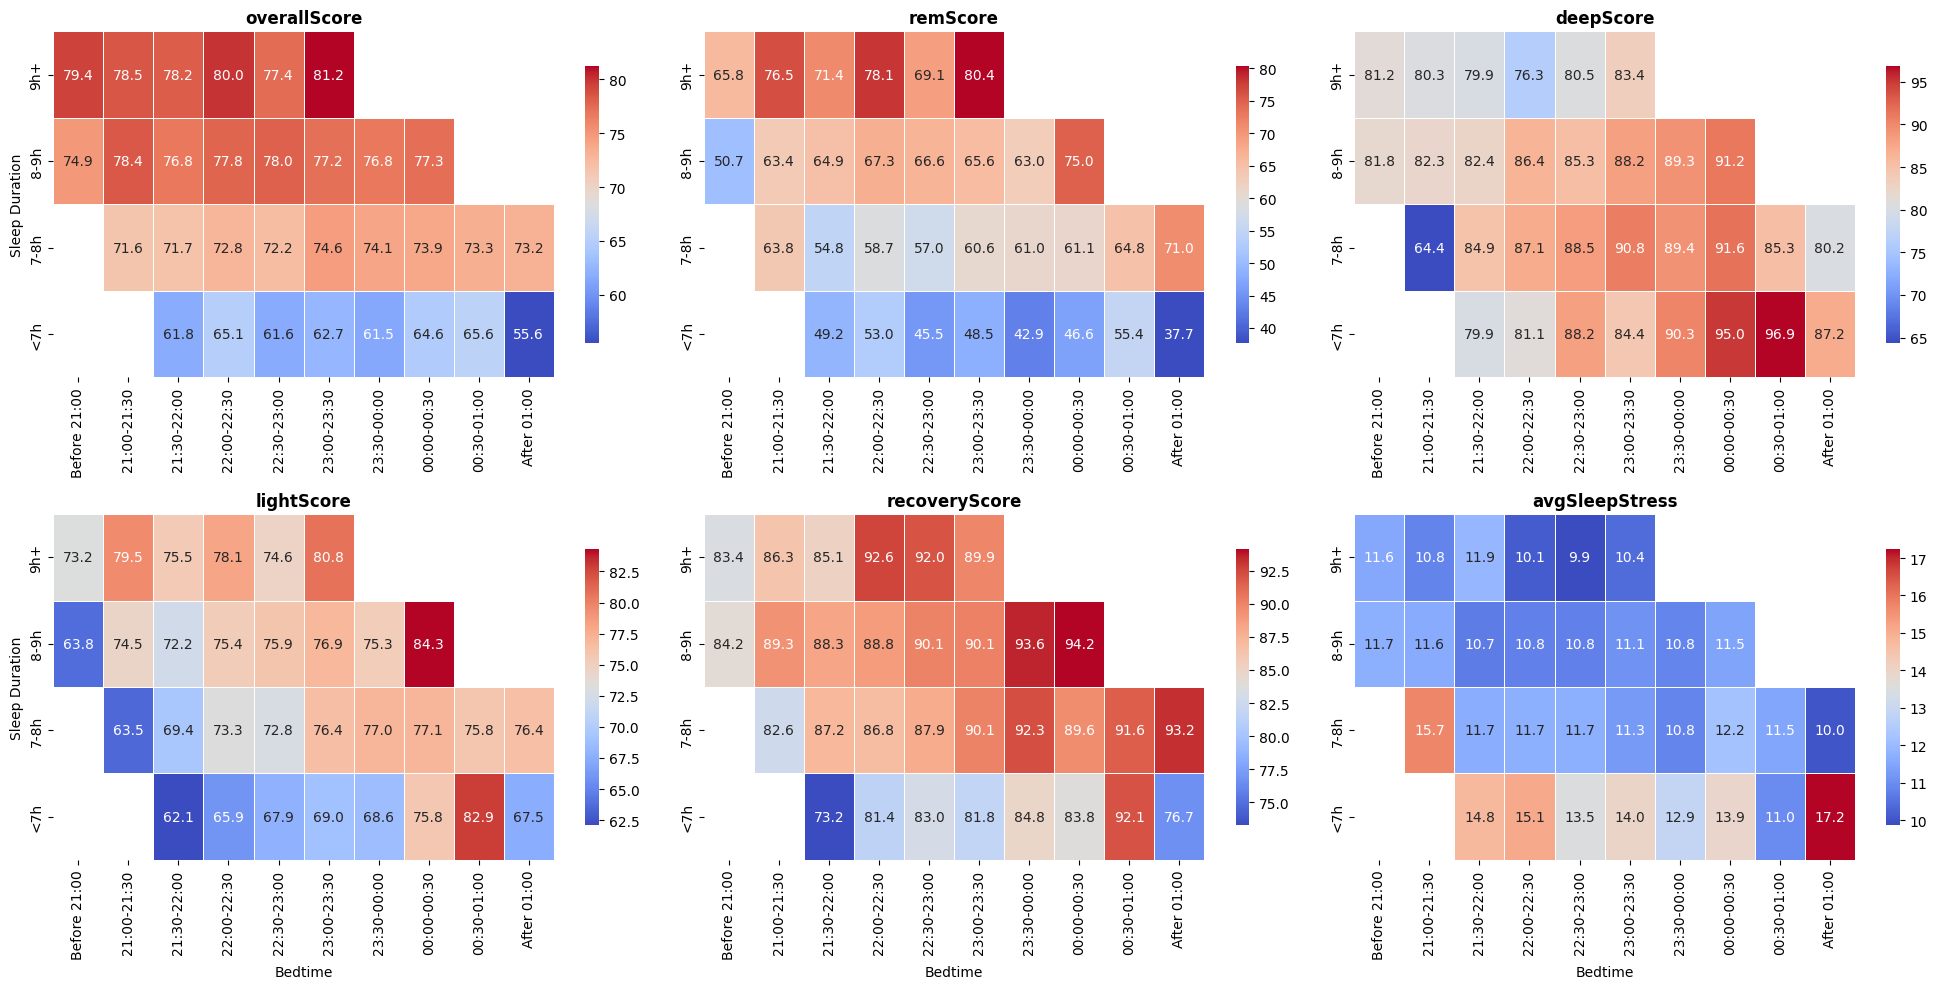

In [13]:
plot_metric_heatmaps(group_stats)

<div class="no-break">

<h2>From Visual Patterns to Statistical Evidence</h2>

<p>
The heatmaps presented above provide an intuitive visual summary of how sleep quality changes across 
combinations of bedtime and sleep duration. They are particularly effective at highlighting broad patterns, 
such as the strong improvement in most sleep metrics as total sleep duration increases.
</p>

<p>
However, while these visualisations are useful for identifying trends, they are not well suited to 
quantifying them. In particular, determining whether bedtime independently influences sleep quality is 
difficult by inspection alone. Differences in sample size between bins, natural night‑to‑night variation, 
and the interaction between bedtime and sleep duration can all obscure the true relationship.
</p>

<p>
To formally evaluate the importance of bedtime, we now move from descriptive visualisation to 
<strong>statistical modelling</strong>.
</p>

</div>

<hr style="margin: 40px 0;">

<div class="no-break">

<h2>Quantifying the Contribution of Bedtime</h2>

<p>
The following analysis uses <strong>hierarchical regression</strong> to measure how much additional information 
bedtime provides once sleep duration has already been taken into account.
</p>

<p>
The measure used throughout is the <strong>coefficient of determination (R²)</strong>, which, as we have already stated, represents the 
proportion of variation in a sleep metric that can be explained by a statistical model.
</p>

<p>
Rather than fitting a single model, predictors are added sequentially:
</p>

<ul style="margin-top: 10px;">
  <li>
    <strong>Sleep duration only:</strong> establishing how much of each sleep metric is explained by total sleep duration.
  </li>

  <li style="margin-top: 10px;">
    <strong>+ Bedtime:</strong> measuring how much additional variation is explained by simply knowing when sleep began.
  </li>

  <li style="margin-top: 10px;">
    <strong>+ Quadratic Bedtime:</strong> allowing the relationship between bedtime and sleep quality to be non‑linear.
  </li>

  <li style="margin-top: 10px;">
    <strong>+ Duration × Bedtime Interaction:</strong> testing whether the influence of bedtime changes depending on 
    how much sleep was obtained.
  </li>
</ul>

<p style="margin-top: 20px;">
By comparing the increase in R² at each stage, we can directly answer the central question of this chapter:
</p>

<div style="margin: 20px 0; padding: 12px; border-left: 4px solid #4CAF50; background: #f9f9f9;">
  <strong>Does bedtime explain variation in sleep quality beyond the effect of sleep duration alone?</strong>
</div>

<p>
The table below summarises the contribution of each modelling stage across all sleep metrics.
</p>

</div>


In [14]:

hierarchical_r2_table = calculate_hierarchical_r2(analysis_df)
display(build_hierarchical_r2_table(hierarchical_r2_table))


Metric,N,Duration R²,Bedtime +ΔR²,Quadratic +ΔR²,Interaction +ΔR²,Total R²,Bedtime p,Quadratic p,Interaction p
overallScore,1305,33.5%,0.4%,1.1%,0.8%,35.8%,0.0042,0.0000,0.0000
remScore,1305,14.6%,0.6%,0.4%,0.0%,15.6%,0.0019,0.0157,0.4189
deepScore,1305,0.4%,1.5%,1.3%,0.4%,3.5%,0.0000,0.0000,0.0185
lightScore,1305,2.5%,2.6%,0.9%,0.1%,6.1%,0.0000,0.0006,0.2617
recoveryScore,1305,6.9%,2.4%,2.5%,2.6%,14.5%,0.0000,0.0000,0.0000
avgSleepStress,1293,11.2%,0.5%,2.0%,1.9%,15.6%,0.0051,0.0000,0.0000


<div class="no-break">

<h2>Interpreting the Hierarchical Regression Results</h2>

<p>
The hierarchical regression models provide a direct answer to the central question of this chapter:
</p>

<div style="margin:20px 0;padding:12px;border-left:4px solid #4CAF50;background:#f9f9f9;">
<strong>Does bedtime influence sleep quality beyond its effect on total sleep duration?</strong>
</div>

<p>
The answer is <strong>yes</strong>.
For every sleep metric, adding bedtime to a model that already contains sleep duration improves the amount of variation that can be explained. In several cases, allowing bedtime to follow a non-linear (quadratic) relationship provides an additional improvement, indicating that the effects of bedtime become stronger as bedtimes drift progressively later.
</p>

</div>

<hr style="margin:40px 0;">

<div>

<h3>Understanding the Additional R² Contributions</h3>

<p>
Each column asks a slightly different question about what determines nightly sleep quality.
Rather than replacing the previous model, each stage builds upon it to test whether another factor explains additional variation.
</p>

<table style="width:100%;border-collapse:collapse;margin-top:20px;">
<thead>
<tr style="background:#f2f2f2;">
<th style="padding:8px;">Model Component</th>
<th style="padding:8px;">Question Being Asked</th>
<th style="padding:8px;">Interpretation</th>
</tr>
</thead>

<tbody>

<tr>
<td style="padding:8px;"><strong>Duration R²</strong></td>
<td style="padding:8px;">How much can sleep quality be explained using sleep duration alone?</td>
<td style="padding:8px;">This forms the baseline model. For example, sleep duration alone explains <strong>33.5%</strong> of the variation in <code>overallScore</code>.</td>
</tr>

<tr>
<td style="padding:8px;"><strong>Bedtime +ΔR²</strong></td>
<td style="padding:8px;">If two nights contain the same amount of sleep, does knowing the bedtime improve our prediction?</td>
<td style="padding:8px;">Any increase here represents the independent contribution of bedtime beyond total sleep duration (e.g. <strong>1.5%</strong> for <code>deepScore</code> and <strong>2.4%</strong> for <code>recoveryScore</code>).</td>
</tr>

<tr>
<td style="padding:8px;"><strong>Quadratic +ΔR²</strong></td>
<td style="padding:8px;">Does the effect of bedtime remain constant throughout the night?</td>
<td style="padding:8px;">This captures the additional improvement gained by allowing bedtime to follow a curved relationship, suggesting that very late bedtimes may carry a disproportionately larger penalty.</td>
</tr>

<tr>
<td style="padding:8px;"><strong>Interaction +ΔR²</strong></td>
<td style="padding:8px;">Does the importance of bedtime depend on how much sleep was obtained?</td>
<td style="padding:8px;">A significant interaction indicates that the effect of bedtime changes across different sleep durations rather than remaining constant.</td>
</tr>

</tbody>
</table>

<h3 style="margin-top:35px;">What Do These Results Tell Us?</h3>

<p>
Sleep duration remains the strongest predictor of Garmin's composite <code>overallScore</code>, explaining approximately <strong>33.5%</strong> of the observed variation. Once sleep duration has been accounted for, bedtime still contributes an additional <strong>0.4%</strong>, with a further <strong>1.1%</strong> explained by allowing a non-linear bedtime effect. Although modest, these improvements are statistically significant, demonstrating that bedtime contains information beyond simply how long sleep lasted.
</p>

<p>
The additional contribution of bedtime is much larger for physiological metrics such as <code>deepScore</code>, <code>lightScore</code>, <code>recoveryScore</code>, and <code>avgSleepStress</code>. For example, bedtime explains an additional <strong>2.4%</strong> of the variation in <code>recoveryScore</code>, while the interaction term contributes a further <strong>2.6%</strong>, indicating that the influence of bedtime becomes more important under certain sleep durations.
</p>

<p>
Overall, the results show that <strong>sleep duration determines most of the variation in overall sleep quality, but bedtime provides additional predictive value across every metric.</strong> Importantly, the significant interaction terms suggest that bedtime does not have a fixed effect - instead, its importance changes depending on how much sleep is obtained.
</p>

<div style="margin:25px 0;padding:12px;border-left:4px solid #4CAF50;background:#f9f9f9;">
<strong>This naturally leads to the final question:</strong><br><br>
Does bedtime contribute equally on every night, or does its importance change between short, average and long sleep durations?
</div>

<p>
To answer this, the same hierarchical regression is repeated separately within different sleep-duration groups, allowing the contribution of bedtime to be compared across short, typical and long nights.
</p>

</div>

<p style="page-break-after:always;"></p>

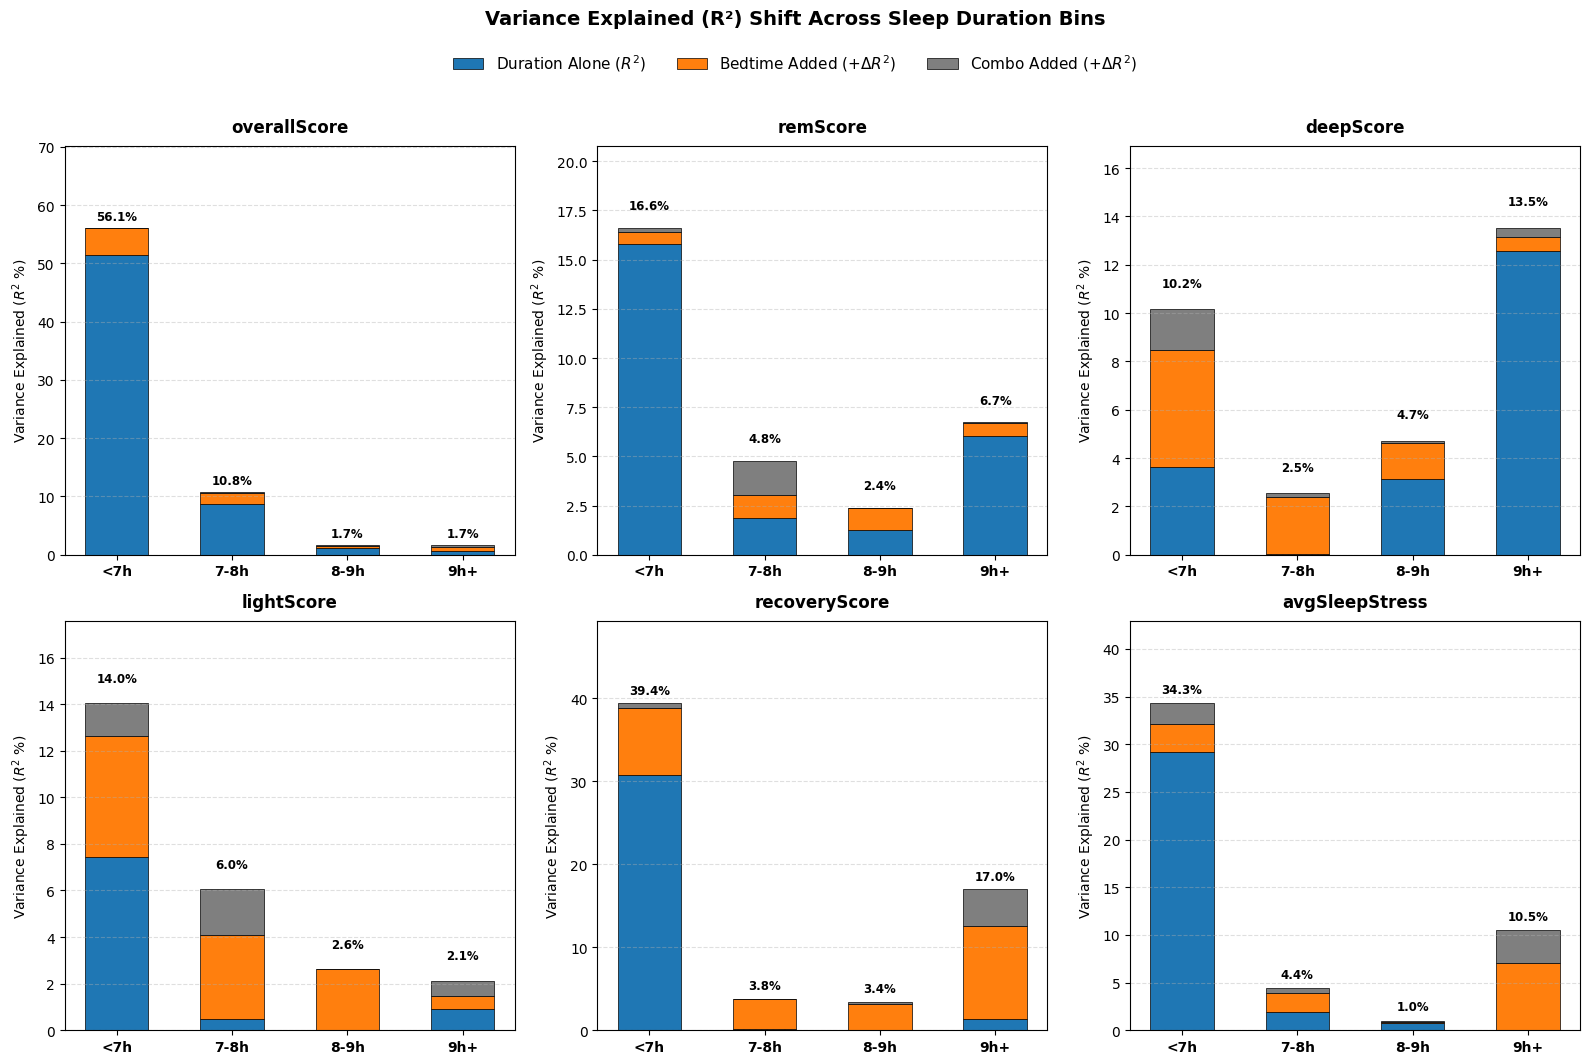

In [15]:
breakdown_df = calculate_binned_r2_breakdown(analysis_df)

plot_r2_breakdown(breakdown_df)


<div>

<h2>Overall Score</h2>

<p>
The contribution of sleep duration is greatest when sleep is restricted (&lt;7 hours), where it explains approximately <strong>51%</strong> of the variation in overall score. Once sleep extends beyond 7 hours, the explanatory power of duration falls rapidly, indicating that simply sleeping longer provides diminishing returns. Bedtime contributes only a modest amount throughout, suggesting that Garmin's composite <code>overallScore</code> remains primarily driven by total sleep quantity.
</p>

<h2>REM Score</h2>

<p>
REM sleep is strongly linked to sleep duration during short nights, consistent with REM-rich sleep occurring predominantly in the later sleep cycles. As sleep duration increases, bedtime becomes relatively more important, indicating that circadian timing contributes to REM quality once sufficient sleep opportunity is available. At the longest sleep durations, duration again explains more variation, likely reflecting access to additional REM-rich cycles.
</p>

<h2>Deep Score</h2>

<p>
Deep sleep displays the strongest relationship with bedtime. During short and typical nights, bedtime consistently explains more variation than sleep duration, suggesting that <strong>when</strong> sleep begins is more important than simply sleeping longer. Only during the longest sleep durations does duration begin to regain importance, implying that both sleep opportunity and circadian timing contribute to deep-sleep quality.
</p>

<h2>Light Score</h2>

<p>
Light sleep is the least predictable of the measured metrics. Across every sleep-duration group, both sleep duration and bedtime explain relatively little of the observed variation, suggesting that light sleep is influenced more heavily by factors outside the scope of this notebook, such as daily activity, environmental conditions, or measurement variability.
</p>

<h2>Recovery Score</h2>

<p>
Recovery score demonstrates one of the clearest shifts in importance. Sleep duration dominates when sleep is restricted, but as sleep duration approaches normal levels, bedtime contributes an increasingly larger proportion of the explained variation. At the longest sleep durations, bedtime explains more variation than sleep duration, suggesting that recovery depends not only on obtaining sufficient sleep, but also on maintaining an appropriate sleep schedule.
</p>

<h2>Average Sleep Stress</h2>

<p>
Average sleep stress follows a similar pattern to recovery. Sleep duration is the primary driver during short nights, whereas bedtime becomes increasingly important once sufficient sleep has been obtained. This suggests that extending sleep alone may not fully optimise overnight recovery if sleep timing is consistently delayed.
</p>

<hr style="margin:40px 0;">

<h2>Overall Interpretation</h2>

<p>
The hierarchical analysis demonstrates that the relative importance of sleep duration and bedtime changes across different sleep lengths.
</p>

<p>
When sleep duration is restricted (&lt;7 hours), <strong>obtaining more sleep is consistently the most effective way to improve sleep quality.</strong> Across almost every metric, sleep duration explains substantially more variation than bedtime, indicating that the physiological cost of insufficient sleep outweighs differences in sleep timing.
</p>

<p>
Once sleep reaches approximately <strong>7–9 hours</strong>, the influence of sleep duration begins to plateau. At this point, bedtime explains an increasing proportion of the remaining variation, particularly for <code>deepScore</code>, <code>recoveryScore</code>, and <code>avgSleepStress</code>. This suggests that after sufficient sleep has been achieved, optimising <strong>when</strong> sleep occurs may provide additional benefits beyond simply sleeping longer.
</p>

<p>
For several metrics, the interaction between bedtime and sleep duration is also substantial. Rather than acting independently, late bedtimes and insufficient sleep reinforce one another, producing larger reductions in sleep quality than either factor alone.
</p>

<p>
Overall, the results demonstrate that <strong>sleep duration establishes the baseline for sleep quality, while bedtime modifies that baseline.</strong> The balance between the two depends on how much sleep is obtained.
</p>

<hr style="margin:40px 0;">

<h2>Conclusion & Limitations</h2>

<h3>Project Conclusion</h3>

<p>
Using over <strong>1,300 nights</strong> of Garmin sleep data, this notebook investigated whether bedtime influences sleep quality beyond simply reducing total sleep duration.
</p>

<p>
The results consistently show that <strong>sleep duration is the strongest predictor of overall sleep quality</strong>, explaining approximately <strong>33%</strong> of the variation in Garmin's composite sleep score. However, bedtime contributes independently across every sleep metric analysed. Even after accounting for sleep duration, later bedtimes explain additional variation in measures such as <code>deepScore</code>, <code>recoveryScore</code>, and <code>avgSleepStress</code>, demonstrating that sleep timing carries meaningful information beyond sleep quantity alone.
</p>

<p>
Perhaps the most important finding is that the effect of bedtime is <strong>not constant</strong>. Its importance changes depending on how much sleep is obtained. When sleep is restricted, increasing sleep duration provides the greatest improvement. Once sufficient sleep is achieved, however, bedtime becomes increasingly influential for several physiological measures. In other words, <strong>late bedtimes and insufficient sleep compound one another</strong>, creating a larger penalty than either factor in isolation.
</p>

<p>
Although these findings are specific to a single individual, they demonstrate how long-term wearable data can be combined with statistical modelling to separate highly correlated behaviours and provide meaningful insight into personal sleep habits.
</p>

<h3>Key Limitations</h3>

<ul>

<li><strong>Single-participant dataset:</strong> These findings describe one individual's sleep behaviour and should not be generalised to wider populations.</li>

<li><strong>Observational data:</strong> Statistical relationships do not imply causation. Other factors such as illness, alcohol, caffeine, training load, stress, or lifestyle may contribute to the observed patterns.</li>

<li><strong>Temporal dependence:</strong> Consecutive nights are unlikely to be completely independent, as sleep debt and recovery accumulate over multiple days.</li>

<li><strong>Garmin-derived metrics:</strong> Sleep stages and scores are estimated using proprietary consumer algorithms rather than clinical polysomnography.</li>

<li><strong>Scope of analysis:</strong> This notebook focuses specifically on bedtime and sleep duration. The following notebooks investigate how daily activity, exercise, physiological measurements, and lifestyle behaviours further influence sleep quality.</li>

</ul>

</div>